
1. https://www.moviechart.co.kr/rank/realtime/index/image 를 파싱하여 
아래처럼 출력하시요

```
데이터프레임 결과임

영화명    예매율    개봉일        등급       장르       감독  
===============================================================    
모비우스     39.5    2022.03.30  15세이상 액션/어드벤처/공포/SF
.....
```

In [48]:
from bs4 import BeautifulSoup
from urllib.request import urlopen
import re
import pandas as pd


murl = 'https://www.moviechart.co.kr/rank/realtime/index/image'
response = urlopen(murl)
html = BeautifulSoup(response, 'html.parser')
base_url = "http://www.moviechart.co.kr"

href = []
for a in html.select( '.movieBox-item > a'):
    href.append(a['href'])

m_info_list = []


for h in href:
    response = urlopen(base_url + h)
    html = BeautifulSoup(response, 'html.parser')
    
    m_title = html.select_one('.movieIner__title > div').contents[0].strip().replace("극장판 ", "")
    m_rate = html.select_one('ul.movieInerInfo-list dl:nth-of-type(1) dt').string.strip().split()[1]
    m_rate_float = float(m_rate.replace("%", ""))
    second_list = html.select_one('ul.movieInerInfo-list li:nth-of-type(2) dt').string.strip()
    match = re.search(r"\d{4}.\d{2}.\d{2}", second_list)
    if match:
        m_openday = match.group()
    m_class = rating = second_list.split("/")[-1].strip()
    m_genre = second_list.split("/")[0].strip()
    m_director = html.select_one('ul.movieInerInfo-list li:nth-of-type(3) dt').string.strip()

    m_info_list.append( {'영화명':m_title,
                   '예매율':m_rate_float,
                   '개봉일':m_openday,
                    '등급':m_class,
                    '장르':m_genre,
                    '감독':m_director } )

m_df = pd.DataFrame(m_info_list)
m_df

,영화명,예매율,개봉일,등급,장르,감독
0,치이카와: 인어 섬의 비밀,39.0,2026.09.30,전체관람가,애니메이션,오이카와 케이
1,암살자(들),13.8,2026.09.23,12세이상관람가,"범죄,드라마",허진호
2,오디세이,10.5,2026.08.05,15세이상관람가,"액션,드라마,어드벤처",크리스토퍼 놀란
3,타짜: 벨제붑의 노래,9.5,2026.09.23,청소년관람불가,"범죄,드라마",최국희
4,부활남: 더 레드,7.8,2026.09.30,15세이상관람가,액션,백종열
5,가능한 사랑,3.8,2026.09.23,청소년관람불가,드라마,이창동
6,디거,2.6,2026.10.03,15세이상관람가,"코미디,드라마",알레한드로 곤잘레스 이냐리투
7,인턴,2.3,2026.09.16,12세이상관람가,드라마,김도영
8,어벤져스: 엔드게임 앙코르,1.9,2026.09.23,12세이상관람가,"액션,SF",조 루소
9,옵세션,1.1,2026.09.02,청소년관람불가,공포(호러),커리 바커



2. 위의 결과를 데이터프레임으로 변환후 예매율이 10.0 이상인 영화명 예매율 개봉일을 출력하시요

In [148]:
m_df.query('예매율 > 10')[['영화명', '예매율', '개봉일']]


,영화명,예매율,개봉일
0,치이카와: 인어 섬의 비밀,39.0,2026.09.30
1,암살자(들),13.8,2026.09.23
2,오디세이,10.5,2026.08.05



3. x축을 영화명 으로 y축을 예매율로 바차트를 그리시요

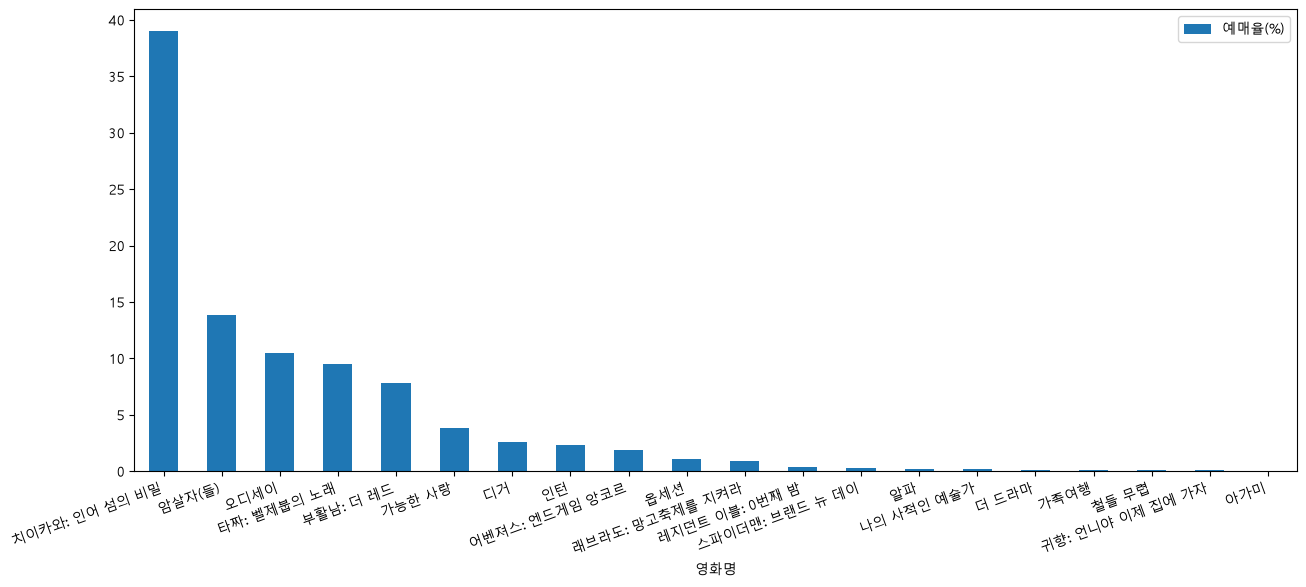

In [150]:
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

m_df.plot( kind='bar', x='영화명' , y='예매율', rot=20, figsize=(15,6))
plt.xticks(rotation=20, ha="right")
plt.legend(['예매율(%)'])
plt.show()


4. 2026년 09월 25일 이후 개봉한 영화명,예매율,개봉일을 구하시요

In [151]:
m_df[pd.to_datetime(m_df['개봉일'], format='%Y.%m.%d') > '2026-09-25'][['영화명', '예매율', '개봉일']]

,영화명,예매율,개봉일
0,치이카와: 인어 섬의 비밀,39.0,2026.09.30
4,부활남: 더 레드,7.8,2026.09.30
6,디거,2.6,2026.10.03
10,래브라도: 망고축제를 지켜라,0.9,2026.10.03
13,알파,0.2,2026.09.30



5.  예매율 10.0 이상과 나머지의 비율을 파이차트로 그리시요

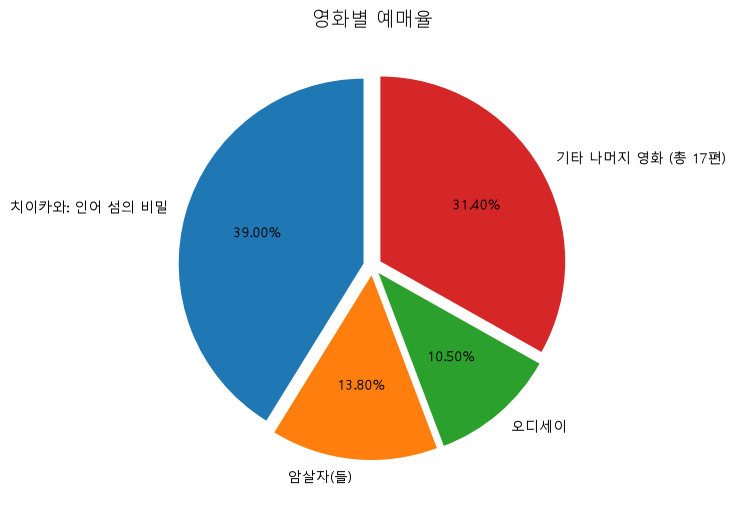

In [152]:
df_over_10 = m_df[m_df['예매율'] >= 10].copy()
df_rest = m_df[m_df['예매율'] < 10]

if not df_rest.empty:
    summary_rest = pd.DataFrame([{
        '영화명': f"기타 나머지 영화 (총 {len(df_rest)}편)", 
        '예매율': df_rest['예매율'].sum(),                
    }])
    result = pd.concat([df_over_10, summary_rest], ignore_index=True)
else:
    result = df_over_10

df_pie = result.set_index('영화명')

plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    result['예매율'], 
    labels=df_pie.index,       
    autopct='%1.1f',           
    explode=[0.05] * len(result),
    startangle=90,
)

for i, a in enumerate(autotexts):
    original_val = result['예매율'].iloc[i]
    a.set_text(f'{original_val:.2f}%') 

plt.title('영화별 예매율', fontsize=14)
plt.show()


6. 예매율 top5를 구하시요

In [154]:
m_df.nlargest(5, '예매율', keep="all")

,영화명,예매율,개봉일,등급,장르,감독
0,치이카와: 인어 섬의 비밀,39.0,2026.09.30,전체관람가,애니메이션,오이카와 케이
1,암살자(들),13.8,2026.09.23,12세이상관람가,"범죄,드라마",허진호
2,오디세이,10.5,2026.08.05,15세이상관람가,"액션,드라마,어드벤처",크리스토퍼 놀란
3,타짜: 벨제붑의 노래,9.5,2026.09.23,청소년관람불가,"범죄,드라마",최국희
4,부활남: 더 레드,7.8,2026.09.30,15세이상관람가,액션,백종열



7. 장르가 드라마 데이터를 출력하시요

In [155]:
m_df.query("장르.str.contains('드라마', na=False)")

,영화명,예매율,개봉일,등급,장르,감독
1,암살자(들),13.8,2026.09.23,12세이상관람가,"범죄,드라마",허진호
2,오디세이,10.5,2026.08.05,15세이상관람가,"액션,드라마,어드벤처",크리스토퍼 놀란
3,타짜: 벨제붑의 노래,9.5,2026.09.23,청소년관람불가,"범죄,드라마",최국희
5,가능한 사랑,3.8,2026.09.23,청소년관람불가,드라마,이창동
6,디거,2.6,2026.10.03,15세이상관람가,"코미디,드라마",알레한드로 곤잘레스 이냐리투
7,인턴,2.3,2026.09.16,12세이상관람가,드라마,김도영
13,알파,0.2,2026.09.30,15세이상관람가,드라마,쥘리아 뒤쿠르노
14,나의 사적인 예술가,0.2,2026.09.23,15세이상관람가,드라마,켄트 존스
15,더 드라마,0.1,2026.09.09,15세이상관람가,"드라마,멜로",크리스토퍼 보글리
16,가족여행,0.1,2026.09.01,12세이상관람가,"가족,드라마",김정태



8. 등급별 비율을 파이차트로 그리시요

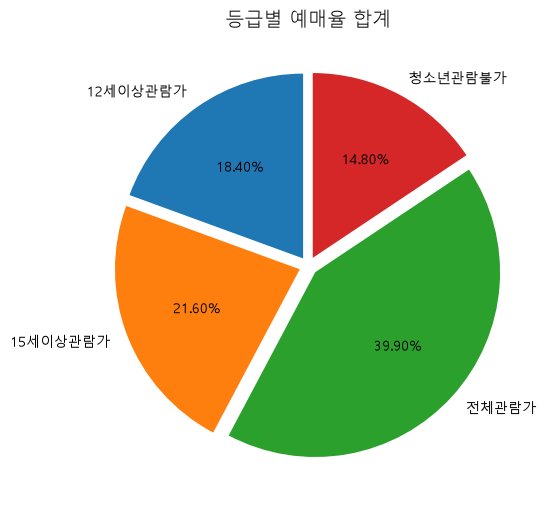

In [156]:
grouped = m_df.groupby('등급')['예매율'].sum()

# 예매율 합계 값 그대로 사용
class_result_df = pd.DataFrame({
    '예매율_합계': grouped
})

plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    class_result_df['예매율_합계'], 
    labels=class_result_df.index,       
    autopct='%1.1f',        
    explode=[0.05] * len(class_result_df),
    startangle=90
)

for i, a in enumerate(autotexts):
    original_val2 = class_result_df['예매율_합계'].iloc[i]
    a.set_text(f'{original_val2:.2f}%')

plt.title('등급별 예매율 합계', fontsize=14)
plt.show()